# Running estimation on simulated data

## Simulation

The simulation runs as follows:
- Set a window size of lenght s
- $\beta_s$ is initialized as 0
- The first $\beta$ computed by the agents is $\beta_{s+1}$ obtained by regressing $(r_{1} \dots r_{s})$ on $(x_0 \dots x_{s-1})$
- Two predictions are computed: $\beta_s x_s = \hat{r}_{s+1}$ and $\beta_{s+1} x_{s+1} = \hat{r}_{s+2}$
- The actual return $r_{s+1}$ is computed by the ALM as a function of $\hat{r}_{s+1}$ and $\hat{r}_{s+2}$

In [1]:
import os
os.getcwd()
os.chdir('/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/scripts/lasso_11_2025')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tommasodifrancesco/Desktop/Lasso_paper/Empirical/scripts/lasso_11_2025'

In [ ]:
# Generate simulated data for testing purposes

import matplotlib.pyplot as plt

import pandas as pd
import csv
import pickle
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import os
import random
from itertools import product



from stage1 import lasso_rolling_window, calculate_r_squared, create_lagged_features

from stage2 import estimate_kappa_curve_fit, compute_alm_returns, compute_stage2_r_squared
from grid_search import estimate_single_config

In [ ]:
#loading data
df = pd.read_csv('/Users/tommasodifrancesco/Desktop/Lasso_paper/Theory/simulation_data_offline_lasso.csv')

In [ ]:
# data
y = df['r'].values
betas = df.filter(like='beta_').values
df = df.drop(columns=['r'])

#drop column if name starts with beta_
X = df.loc[:, ~df.columns.str.startswith('beta_')].values

#drop first column which is index
X = X[:,1:]
random.seed(42)


In [ ]:
window_size = 300
n_lags = 1
lambda_val = 0.00001

In [ ]:
# # Stage 1: Rolling LASSO + OLS
# stage1_results = lasso_rolling_window(
#     X=X, y=y, 
#     window_size=window_size, 
#     n_lags=n_lags,
#     lambda_mode="fixed", 
#     fixed_lambda=lambda_val, 
#     standardize=False,
#     verbose=False # Keep false to avoid spamming console in parallel
# )

In [ ]:
# coefficients = stage1_results['coefficients']
# #remove the first beta estimate as it is obtained by r_0 on x_{-1}
# coefficients = coefficients[1:,:]

In [ ]:
# remove the first window_size rows to align with true betas
true_betas_aligned = betas[window_size:,:]

In [ ]:
# #visualize coefficients vs true betas for first 5 features
# n_features_to_plot = 5
# plt.figure(figsize=(15, 10))
# for i in range(n_features_to_plot):
#     plt.subplot(n_features_to_plot, 1, i + 1)
#     plt.plot(true_betas_aligned[:, i], label='True Beta', color='blue')
#     plt.plot(coefficients[:, i], label='Estimated Beta', color='orange', linestyle='--')
#     plt.title(f'Feature {i+1}')
#     plt.xlabel('Time')
#     plt.ylabel('Coefficient Value')
#     plt.legend()
#     plt.tight_layout()
# plt.show()

In [ ]:
dictionary = estimate_single_config(X, y, window_size, n_lags, lambda_val=lambda_val, standardize=False, verbose=True, save_only_positve_r_squared=False)

In [ ]:
dictionary

{'summary': {'window_size': 300,
  'n_lags': 1,
  'lambda': 1e-05,
  'r2_insample_stage1': np.float64(-0.0013191775608008694),
  'r2_oos_stage1': np.float64(0.005286472254372954),
  'r2_insample_stage2': np.float64(0.112007446869685),
  'r2_oos_stage2': np.float64(0.08911146947199478),
  'kappa': np.float64(0.954935500099212),
  'kappa_tstat': np.float64(774.9617142471833),
  'intercept': np.float64(-7.96886747865951e-05),
  'intercept_tstat': np.float64(-0.773794236097372),
  'n_observations': 9697,
  'n_windows': 9699,
  'n_oos_predictions_stage2': nan},
 'details':       date  window_size  n_lags   lambda  window_index  lasso_intercept  \
 0        0          300       1  0.00001             0              0.0   
 1        1          300       1  0.00001             1              0.0   
 2        2          300       1  0.00001             2              0.0   
 3        3          300       1  0.00001             3              0.0   
 4        4          300       1  0.00001     

In [ ]:
details = dictionary['details']

In [ ]:
details

,date,window_size,n_lags,lambda,window_index,lasso_intercept,lasso_r2_in,num_nonzero_coefficients,Lasso_feature_0_lag_1,Lasso_feature_1_lag_1,...,Lasso_feature_10_lag_1,Lasso_feature_11_lag_1,Lasso_feature_12_lag_1,Lasso_feature_13_lag_1,Lasso_feature_14_lag_1,Lasso_feature_15_lag_1,Lasso_feature_16_lag_1,Lasso_feature_17_lag_1,Lasso_feature_18_lag_1,Lasso_feature_19_lag_1
0,0,300,1,0.00001,0,0.0,-0.713727,0.0,-0.0,0.0,...,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
1,1,300,1,0.00001,1,0.0,-0.043605,0.0,-0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0
2,2,300,1,0.00001,2,0.0,-0.025864,0.0,-0.0,-0.0,...,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0
3,3,300,1,0.00001,3,0.0,-0.024172,0.0,-0.0,-0.0,...,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
4,4,300,1,0.00001,4,0.0,-0.026741,0.0,-0.0,-0.0,...,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9697,9697,300,1,0.00001,9697,0.0,-0.000085,1.0,-0.0,0.0,...,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0
9698,9698,300,1,0.00001,9698,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9699,9699,300,1,0.00001,9699,0.0,-0.000684,1.0,-0.0,0.0,...,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0
9700,9700,300,1,0.00001,9700,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


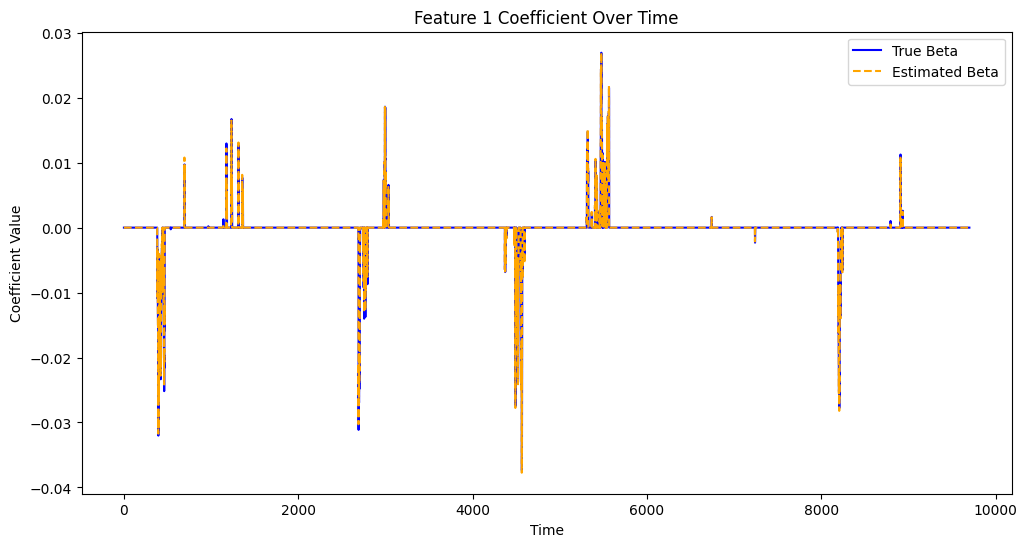

In [ ]:
#visualize first beta vs true beta for first feature
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(true_betas_aligned[:, 0], label='True Beta', color='blue')
ax.plot(details['Lasso_feature_0_lag_1'][0:-2], label='Estimated Beta', color = 'orange', linestyle='--')
ax.set_title('Feature 1 Coefficient Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Coefficient Value')
ax.legend()
plt.show()